# Predicción de Abandono de Clientes (Customer Churn)

## Problema de negocio

Las empresas de telecomunicaciones pierden ingresos cuando los clientes cancelan sus servicios. Anticipar qué clientes tienen mayor probabilidad de abandonar permite actuar de forma proactiva: ofrecer incentivos, mejorar la atención o ajustar los planes antes de que el cliente se vaya.

Este proyecto responde una pregunta concreta:

> **¿Qué clientes tienen mayor riesgo de abandonar la empresa, y qué factores lo explican?**

Los resultados pueden apoyar estrategias de retención

## Objetivo

Construir un modelo de clasificación que prediga el abandono de clientes a partir de sus características de contrato, uso y facturación, e identificar las variables que más influyen en esa decisión.

## Metodología

1. Carga y exploración inicial de datos
2. Limpieza y preparación
3. Análisis estadístico de asociación con el churn (Chi², Cramér's V, tamaño de efecto)
4. Preprocesamiento y entrenamiento de modelos
5. Evaluación y comparación de modelos
6. Interpretabilidad con SHAP
7. Exportación del modelo final

In [1]:
# Librerías estándar
import os

# Librerías de terceros
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# Pruebas estadísticas
from scipy.stats import chi2_contingency, mannwhitneyu

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Carga y exploración inicial de datos

En esta sección se carga el conjunto de datos y se realiza una inspección inicial de su estructura. El objetivo es comprender las variables disponibles, verificar los tipos de datos, identificar posibles valores faltantes y obtener una visión general de la información antes de iniciar cualquier proceso de limpieza o modelado.

In [2]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
os.listdir(path)

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

## Descripción del conjunto de datos

El conjunto de datos **Telco Customer Churn** contiene información de **7,043 clientes** de una empresa de telecomunicaciones. Su objetivo es predecir la variable **Churn**, la cual indica si un cliente canceló o permaneció con el servicio.

Las variables pueden agruparse en las siguientes categorías:

- **Información demográfica:** género (`gender`), adulto mayor (`SeniorCitizen`), pareja (`Partner`) y dependientes (`Dependents`).

- **Servicios contratados:** servicio telefónico (`PhoneService`), múltiples líneas (`MultipleLines`), tipo de servicio de internet (`InternetService`), seguridad en línea (`OnlineSecurity`), respaldo en línea (`OnlineBackup`), protección de dispositivos (`DeviceProtection`), soporte técnico (`TechSupport`), televisión por streaming (`StreamingTV`) y películas por streaming (`StreamingMovies`).

- **Información contractual:** tipo de contrato (`Contract`), facturación electrónica (`PaperlessBilling`) y método de pago (`PaymentMethod`).

- **Información económica:** antigüedad del cliente (`tenure`), cargo mensual (`MonthlyCharges`) y cargo total acumulado (`TotalCharges`).

- **Variable objetivo:** `Churn`, que indica si el cliente canceló el servicio (`Yes`) o permaneció con la compañía (`No`).

Además, el conjunto de datos incluye la variable `customerID`, utilizada únicamente como identificador único de cada cliente y excluida del entrenamiento del modelo.



In [3]:
csv_path = os.path.join(
    path,
    'WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

df = pd.read_csv(csv_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Limpieza y preparación de datos

Antes del análisis es necesario asegurar la calidad de los datos. En esta etapa se corrigen tipos de datos, se tratan los valores faltantes y se realizan las transformaciones necesarias para obtener un conjunto de datos consistente y adecuado para el análisis estadístico y el entrenamiento de modelos de aprendizaje automático.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Distribución del churn

Verificamos qué tan balanceada está la variable objetivo antes de modelar.

In [5]:
df["Churn"].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

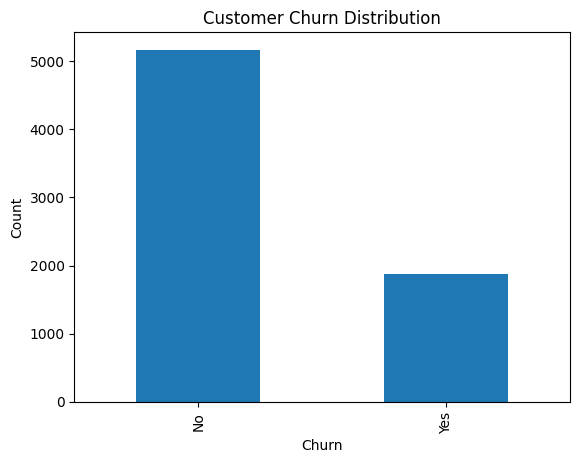

In [6]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

Aproximadamente el **26%** de los clientes cancelaron el servicio (*churn*), mientras que el **74%** permanecieron con la compañía. Esto indica que el conjunto de datos presenta un **desbalance moderado** entre las clases.


### Exploración de variables numéricas y categóricas

In [7]:
for col in df.select_dtypes(include="number"):

    print(df[col].value_counts())

    print("-"*40)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
----------------------------------------
MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
23.65      1
114.70     1
43.65      1
87.80      1
78.70      1
Name: count, Length: 1585, dtype: int64
----------------------------------------


In [8]:
for col in df.select_dtypes(include="object"):

    print(df[col].value_counts())

    print("-"*40)

customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
----------------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------------
OnlineSecurity
No       

## 2.1 Limpieza de datos

`TotalCharges` viene como texto en el dataset original — la convertimos a numérica. Los registros con valores nulos corresponden a clientes nuevos sin cargos registrados aún y se eliminan.

In [9]:
# Convertir TotalCharges a numérica — viene como string en el dataset original
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# SeniorCitizen viene como 0/1 numérico — lo convertimos a categórica para consistencia
df["SeniorCitizen"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

# Verificar valores nulos tras la conversión
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
# Remueve los registros donde recientemente se agregaron clientes y aun no tienen historial de compra 
df = df.dropna(subset=["TotalCharges"])

# 3. Análisis estadístico de asociación con el churn

El objetivo de esta sección es identificar qué variables presentan una asociación significativa con la cancelación del servicio (*churn*). Para ello se utilizan herramientas de estadística inferencial  dependiendo de la variable:

- Para variables **categóricas**: prueba Chi² + Cramér's V (tamaño de efecto)
- Para variables **numéricas**: comparación de medias + tamaño de efecto (Cohen's D)

Las variables categóricas se analizan primero de forma visual y luego con pruebas estadísticas formales.

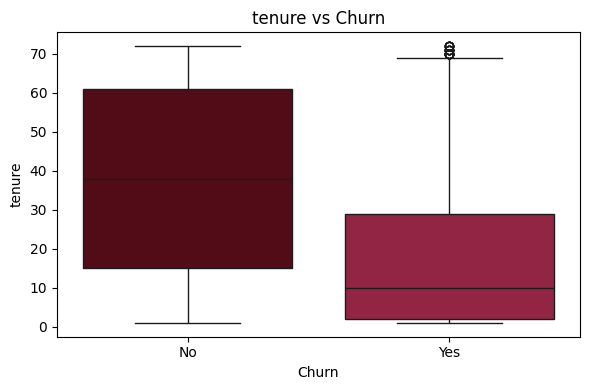

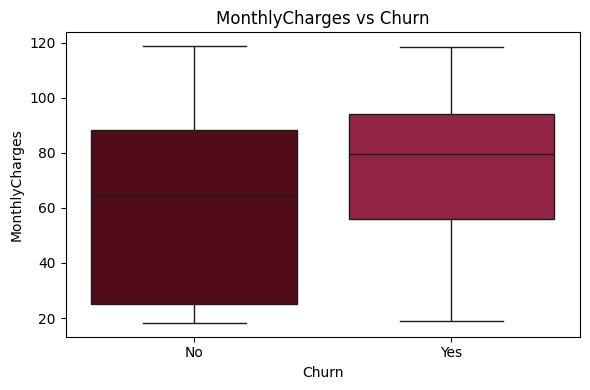

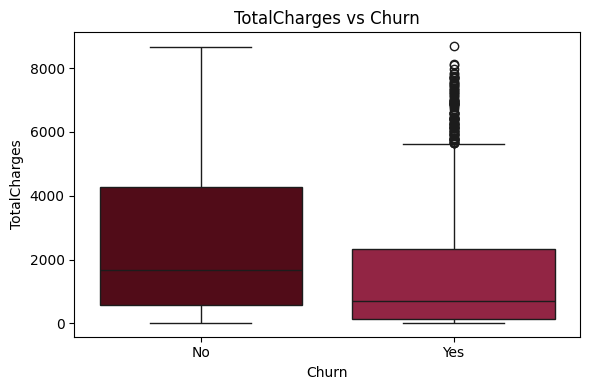

In [12]:

#Obtener columnas categoricas
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols = categorical_cols.drop(["customerID", "Churn"])

# Obtener columnas numéricas
numerical_cols = df.select_dtypes(include="number").columns

# Paleta guinda
palette = {
    "No": "#5C0011",   # Guinda oscuro
    "Yes": "#A4133C"   # Guinda brillante
}

# Graficar
for col in numerical_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        hue="Churn",
        palette=palette,
        legend=False
    )

    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

### Visualización de variables categóricas vs. Churn

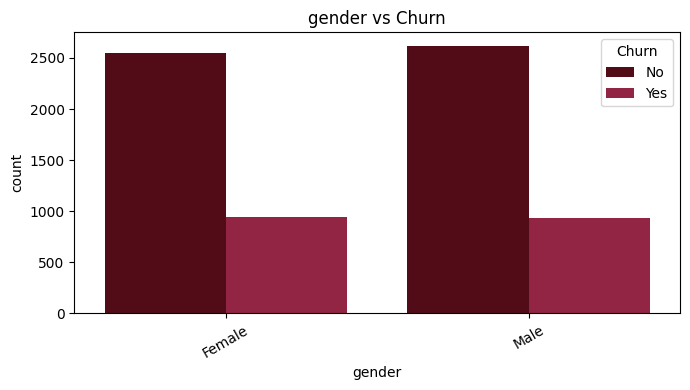

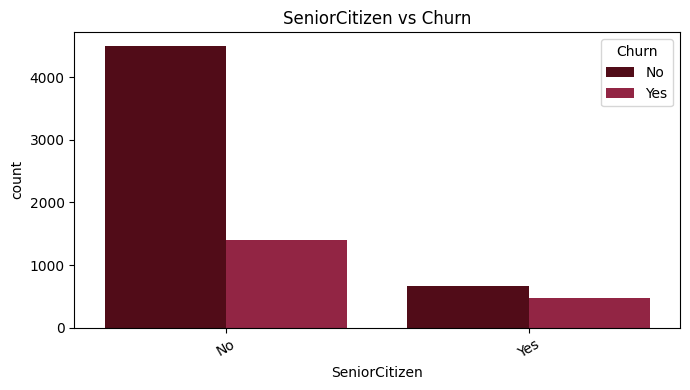

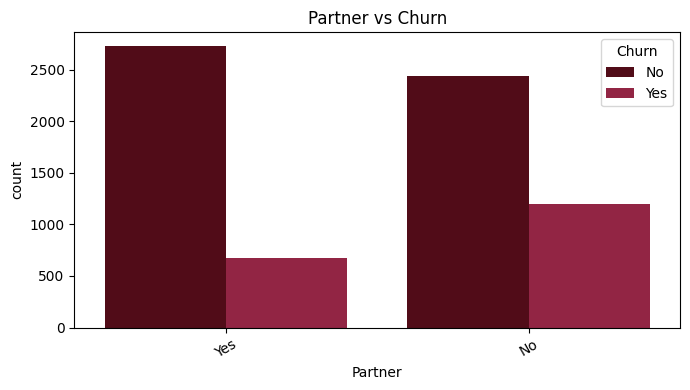

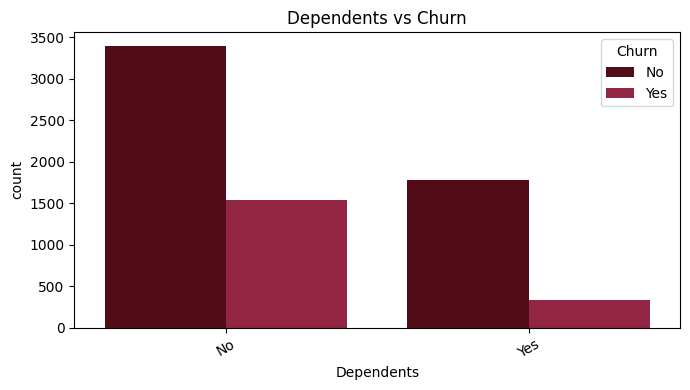

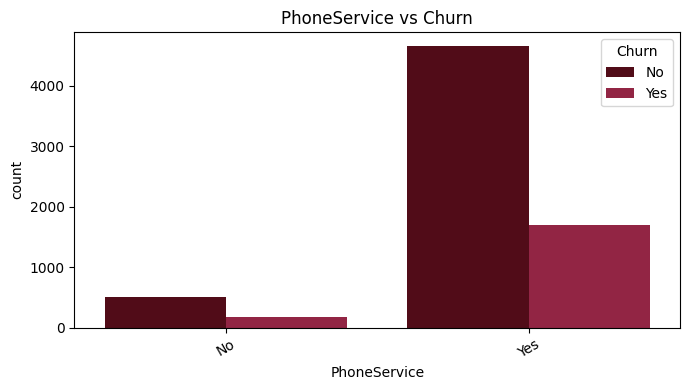

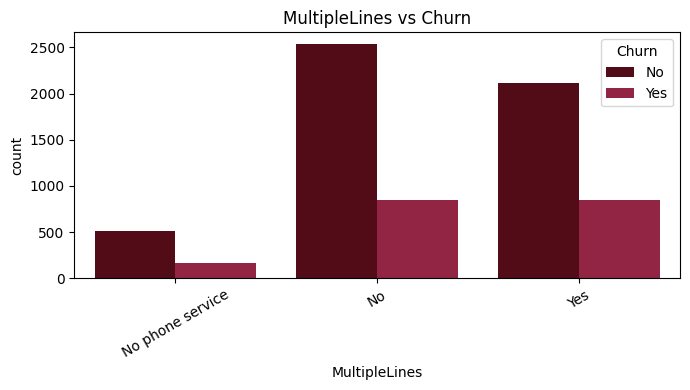

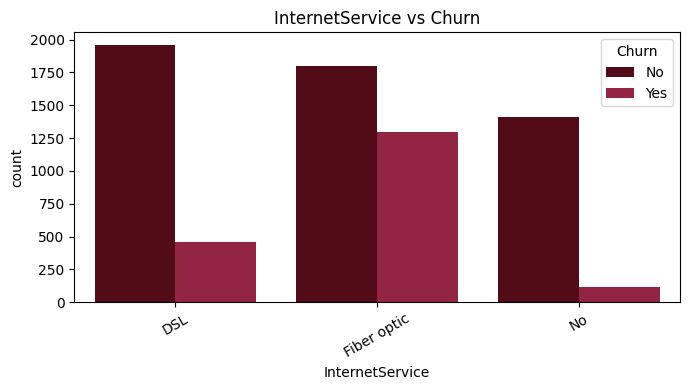

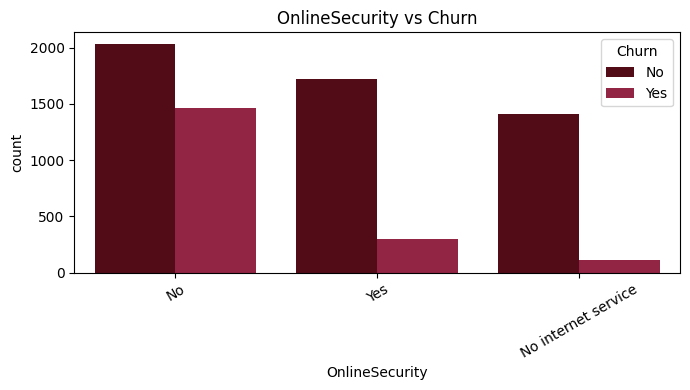

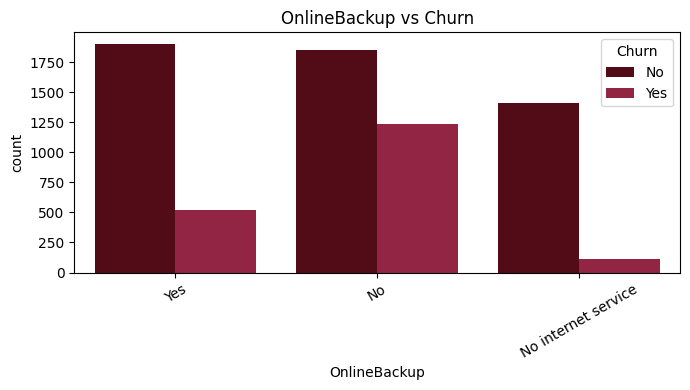

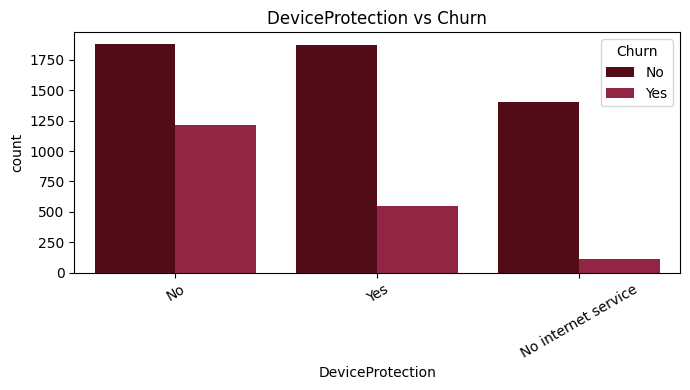

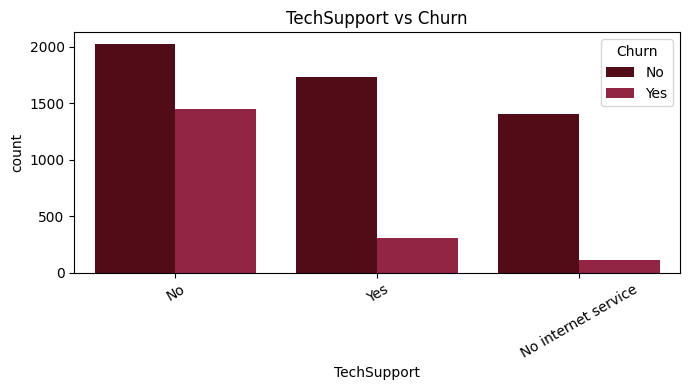

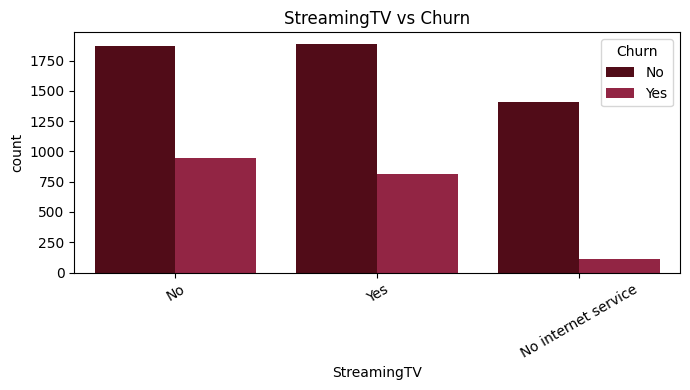

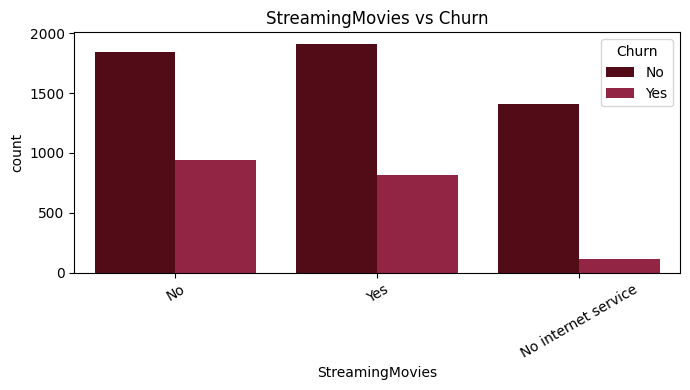

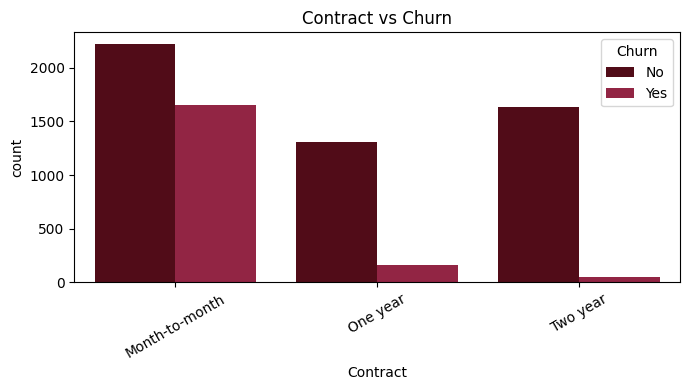

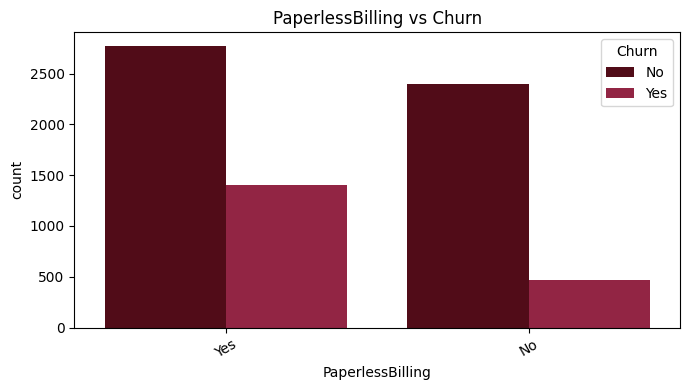

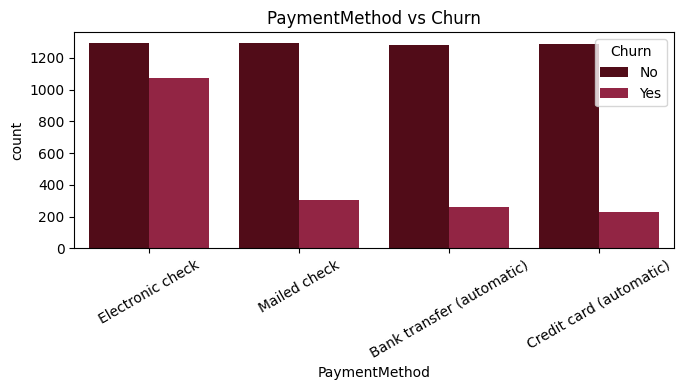

In [13]:
for col in categorical_cols:
    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        palette=palette
    )

    plt.xticks(rotation=30)
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

### Cramér's V — fuerza de asociación para variables categóricas

Cramér's V mide qué tan fuerte es la relación entre cada variable categórica y el churn. Valores cercanos a 1 indican asociación fuerte; cercanos a 0, asociación débil o nula.

In [14]:
def cramers_v(table):
    chi2, p_value, _, _ = chi2_contingency(table)

    n = table.to_numpy().sum()

    r, c = table.shape
    v=np.sqrt(chi2 / (n * (min(r, c) - 1)))
    return v, p_value



summary = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df["Churn"])
    probabilities = pd.crosstab(df[col], df["Churn"], normalize = "index")
    v, p_value = cramers_v(table)

    print("=" * 100)
    print(f"Variable: {col}")
    print("_" * 50)

    display(
        probabilities["Yes"]
        .sort_values( ascending=False)
        .to_frame(f"P(Churn = Yes) | {col}")
        .style
        .format("{:.2%}")
        .background_gradient(cmap="Purples"))
    h_churn = probabilities["Yes"].idxmax()
    p_churn = probabilities["Yes"][h_churn]

    if p_value < 0.05:
        significant = True
        # Association strength
        if v < 0.10:
            strength = "Negligible"
        elif v < 0.20:
            strength = "Weak"
        elif v < 0.40:
            strength = "Moderate"
        else:
            strength = "Strong"
        print(f"P-value             : {p_value:.4g}")
        print(f"Cramér's V          : {v:.1f}")
        
        
        print("✓ There is statistical evidence of an association.\n")
    
        print("Interpretation")
        print(f"- Association strength : {strength}")
        print(f"- Highest-risk group   : {h_churn}")
        print(f"- Churn probability    : {p_churn:.2%}")
        
        
    else:
        significant = False
        print("✗ No statistical evidence of an association.")
    summary.append({
        "Variable": col,
        "Highest Risk Group Value": h_churn,
        "Churn Probability": p_churn,
        "Cramer's V": v,
        "p-value": p_value,
        "Significant": significant
    })

    print("\n")

Variable: gender
__________________________________________________


,P(Churn = Yes) | gender
gender,
Female,26.96%
Male,26.20%


✗ No statistical evidence of an association.


Variable: SeniorCitizen
__________________________________________________


,P(Churn = Yes) | SeniorCitizen
SeniorCitizen,
Yes,41.68%
No,23.65%


P-value             : 2.479e-36
Cramér's V          : 0.2
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Weak
- Highest-risk group   : Yes
- Churn probability    : 41.68%


Variable: Partner
__________________________________________________


,P(Churn = Yes) | Partner
Partner,
No,32.98%
Yes,19.72%


P-value             : 3.974e-36
Cramér's V          : 0.1
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Weak
- Highest-risk group   : No
- Churn probability    : 32.98%


Variable: Dependents
__________________________________________________


,P(Churn = Yes) | Dependents
Dependents,
No,31.28%
Yes,15.53%


P-value             : 2.02e-42
Cramér's V          : 0.2
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Weak
- Highest-risk group   : No
- Churn probability    : 31.28%


Variable: PhoneService
__________________________________________________


,P(Churn = Yes) | PhoneService
PhoneService,
Yes,26.75%
No,25.00%


✗ No statistical evidence of an association.


Variable: MultipleLines
__________________________________________________


,P(Churn = Yes) | MultipleLines
MultipleLines,
Yes,28.65%
No,25.08%
No phone service,25.00%


P-value             : 0.003568
Cramér's V          : 0.0
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Negligible
- Highest-risk group   : Yes
- Churn probability    : 28.65%


Variable: InternetService
__________________________________________________


,P(Churn = Yes) | InternetService
InternetService,
Fiber optic,41.89%
DSL,19.00%
No,7.43%


P-value             : 5.831e-159
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : Fiber optic
- Churn probability    : 41.89%


Variable: OnlineSecurity
__________________________________________________


,P(Churn = Yes) | OnlineSecurity
OnlineSecurity,
No,41.78%
Yes,14.64%
No internet service,7.43%


P-value             : 1.401e-184
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 41.78%


Variable: OnlineBackup
__________________________________________________


,P(Churn = Yes) | OnlineBackup
OnlineBackup,
No,39.94%
Yes,21.57%
No internet service,7.43%


P-value             : 7.776e-131
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 39.94%


Variable: DeviceProtection
__________________________________________________


,P(Churn = Yes) | DeviceProtection
DeviceProtection,
No,39.14%
Yes,22.54%
No internet service,7.43%


P-value             : 1.959e-121
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 39.14%


Variable: TechSupport
__________________________________________________


,P(Churn = Yes) | TechSupport
TechSupport,
No,41.65%
Yes,15.20%
No internet service,7.43%


P-value             : 7.408e-180
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 41.65%


Variable: StreamingTV
__________________________________________________


,P(Churn = Yes) | StreamingTV
StreamingTV,
No,33.54%
Yes,30.11%
No internet service,7.43%


P-value             : 1.325e-81
Cramér's V          : 0.2
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 33.54%


Variable: StreamingMovies
__________________________________________________


,P(Churn = Yes) | StreamingMovies
StreamingMovies,
No,33.73%
Yes,29.95%
No internet service,7.43%


P-value             : 5.354e-82
Cramér's V          : 0.2
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : No
- Churn probability    : 33.73%


Variable: Contract
__________________________________________________


,P(Churn = Yes) | Contract
Contract,
Month-to-month,42.71%
One year,11.28%
Two year,2.85%


P-value             : 7.326e-257
Cramér's V          : 0.4
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Strong
- Highest-risk group   : Month-to-month
- Churn probability    : 42.71%


Variable: PaperlessBilling
__________________________________________________


,P(Churn = Yes) | PaperlessBilling
PaperlessBilling,
Yes,33.59%
No,16.38%


P-value             : 8.236e-58
Cramér's V          : 0.2
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Weak
- Highest-risk group   : Yes
- Churn probability    : 33.59%


Variable: PaymentMethod
__________________________________________________


,P(Churn = Yes) | PaymentMethod
PaymentMethod,
Electronic check,45.29%
Mailed check,19.20%
Bank transfer (automatic),16.73%
Credit card (automatic),15.25%


P-value             : 1.426e-139
Cramér's V          : 0.3
✓ There is statistical evidence of an association.

Interpretation
- Association strength : Moderate
- Highest-risk group   : Electronic check
- Churn probability    : 45.29%




In [15]:
summary = pd.DataFrame(summary)

display(
    summary.sort_values("Cramer's V", ascending=False)
    .reset_index(drop=True)
    .style
    .format({
        "Churn Probability": "{:.2%}",
        "Cramer's V": "{:.3f}",
        "p-value": "{:.4g}"
    })
    .background_gradient(subset=["Cramer's V"], cmap="Purples")
)

,Variable,Highest Risk Group Value,Churn Probability,Cramer's V,p-value,Significant
0,Contract,Month-to-month,42.71%,0.410,7.326e-257,True
1,OnlineSecurity,No,41.78%,0.347,1.401e-184,True
2,TechSupport,No,41.65%,0.343,7.408e-180,True
3,InternetService,Fiber optic,41.89%,0.322,5.831e-159,True
4,PaymentMethod,Electronic check,45.29%,0.303,1.426e-139,True
5,OnlineBackup,No,39.94%,0.292,7.776e-131,True
6,DeviceProtection,No,39.14%,0.281,1.959e-121,True
7,StreamingMovies,No,33.73%,0.231,5.354e-82,True
8,StreamingTV,No,33.54%,0.230,1.325e-81,True
9,PaperlessBilling,Yes,33.59%,0.191,8.236e-58,True


**Observación — Variables categóricas:**

Las variables con mayor asociación estadística con el churn son:

- **Contract** (tipo de contrato): la variable más determinante. Los clientes con contrato mes a mes tienen una probabilidad de abandono significativamente mayor que los de contrato anual o bianual.
- **InternetService**: los clientes con fibra óptica muestran mayor tasa de churn, posiblemente relacionado con cargos mensuales más altos.
- **OnlineSecurity / TechSupport**: los clientes sin estos servicios adicionales tienden más al abandono.

Variables como `gender` y `PhoneService` no mostraron asociación estadísticamente significativa con el churn.

### Tamaño de efecto — variables numéricas vs. Churn

Para las variables numéricas usamos Cohen's D, que mide qué tan diferentes son las distribuciones de cada variable entre clientes que abandonaron y los que se quedaron.

In [16]:
summary2 = []
for col in numerical_cols:

    group_yes = df.loc[df["Churn"] == "Yes", col].dropna()
    group_no  = df.loc[df["Churn"] == "No", col].dropna()

    u_stat, p_value = mannwhitneyu(
        group_yes,
        group_no,
        alternative="two-sided"
    )

    n1 = len(group_yes)
    n2 = len(group_no)
    
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    abs_r = abs(r_rb)

    if abs_r < 0.10:
        strength = "Negligible"
    elif abs_r < 0.30:
        strength = "Small"
    elif abs_r < 0.50:
        strength = "Moderate"
    else:
        strength = "Large"
    summary2.append({
        "Variable" : col,
        "Effect" : abs_r,
        "p value" : p_value,
        "strength" : strength
    })
    print("=" * 60)
    print(f"Variable : {col}")
    print(f"U statistic : {u_stat:.0f}")
    print(f"p-value     : {p_value:.4g}")
    print(f"Rank-biserial : { abs_r:.2%}")
    print(f"Effect size : {strength}")

Variable : tenure
U statistic : 2494979
p-value     : 6.043e-211
Rank-biserial : 48.29%
Effect size : Moderate
Variable : MonthlyCharges
U statistic : 5986148
p-value     : 8.467e-54
Rank-biserial : 24.07%
Effect size : Small
Variable : TotalCharges
U statistic : 3360665
p-value     : 1.996e-84
Rank-biserial : 30.35%
Effect size : Moderate


In [17]:
summary2 = pd.DataFrame(summary2)
display(
    summary2.sort_values("Effect", ascending=False)
    .reset_index(drop=True)
    .style
    .format({
        "Effect" : "{:.2%}",
        "p value" :"{:.4g}",
    })
    .background_gradient(subset=["Effect"], cmap="Purples")
)

display(
    summary.sort_values("Cramer's V", ascending=False)
    .reset_index(drop=True)
    .style
    .format({
        "Churn Probability": "{:.2%}",
        "Cramer's V": "{:.3f}",
        "p-value": "{:.4g}"
    })
    .background_gradient(subset=["Cramer's V"], cmap="Purples")
)


,Variable,Effect,p value,strength
0,tenure,48.29%,6.043e-211,Moderate
1,TotalCharges,30.35%,1.996e-84,Moderate
2,MonthlyCharges,24.07%,8.467e-54,Small


,Variable,Highest Risk Group Value,Churn Probability,Cramer's V,p-value,Significant
0,Contract,Month-to-month,42.71%,0.410,7.326e-257,True
1,OnlineSecurity,No,41.78%,0.347,1.401e-184,True
2,TechSupport,No,41.65%,0.343,7.408e-180,True
3,InternetService,Fiber optic,41.89%,0.322,5.831e-159,True
4,PaymentMethod,Electronic check,45.29%,0.303,1.426e-139,True
5,OnlineBackup,No,39.94%,0.292,7.776e-131,True
6,DeviceProtection,No,39.14%,0.281,1.959e-121,True
7,StreamingMovies,No,33.73%,0.231,5.354e-82,True
8,StreamingTV,No,33.54%,0.230,1.325e-81,True
9,PaperlessBilling,Yes,33.59%,0.191,8.236e-58,True


**Observación — Variables numéricas:**

- **Tenure** (meses como cliente): mayor efecto de las tres variables. A más antigüedad, menor riesgo de churn — los clientes nuevos son el grupo más vulnerable.
- **MonthlyCharges**: los clientes que pagan más mensualmente tienen mayor tendencia al abandono.
- **TotalCharges**: efecto menor una vez que se controla por tenure, ya que ambas variables están correlacionadas.

Estas tres variables serán especialmente relevantes en el modelado y en el análisis SHAP posterior.

# 4. Preprocesamiento y entrenamiento de modelos

Una vez comprendidos los datos, se prepara la información para el modelado mediante un pipeline de preprocesamiento que automatiza la codificación de variables categóricas y el escalamiento de variables numéricas. Posteriormente se entrenan distintos algoritmos de clasificación con el objetivo de predecir la probabilidad de churn de cada cliente.


In [18]:
def load_data():
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")

    csv_path = os.path.join(
        path,
        "WA_Fn-UseC_-Telco-Customer-Churn.csv"
    )

    df = pd.read_csv(csv_path)

    # Convert TotalCharges to numeric
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    # Remove customers with missing charges
    df = df.dropna(subset=["TotalCharges"])

    # Convert SeniorCitizen to categorical labels
    df["SeniorCitizen"] = df["SeniorCitizen"].map({
        0: "No",
        1: "Yes"
    })

    return df

In [19]:
df = load_data()
categorical_cols = (
    df.select_dtypes(include="object")
      .columns
      .drop(["customerID", "Churn"])
)

numerical_cols = (
    df.select_dtypes(include="number")
      .columns
)

In [20]:
# Separar features (X) y variable objetivo (y)
X = df.drop(columns=["customerID", "Churn"])

# Convertir churn a binario: No=0, Yes=1
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# División 80/20 con estratificación para mantener la proporción de churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  # mantiene la proporción de churn (~26%) en train y test
    random_state=42
)

In [21]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numerical_features = X_train.select_dtypes(include="number").columns.tolist()

In [22]:
# Pipeline de preprocesamiento:
# - One-Hot Encoding para categóricas (maneja categorías no vistas en producción con handle_unknown='ignore')
# - StandardScaler para numéricas (normaliza a media=0, std=1 para que KMeans/LR no penalice por escala)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

### Modelo inicial: Regresión Logística

Empezamos con un modelo interpretable como línea base antes de probar modelos más complejos.

In [23]:
# Pipeline completo: preprocesamiento + modelo en un solo objeto
# Esto garantiza que el mismo preprocesamiento se aplique siempre, tanto en entrenamiento como en producción
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [24]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
pipeline.classes_

array([0, 1])

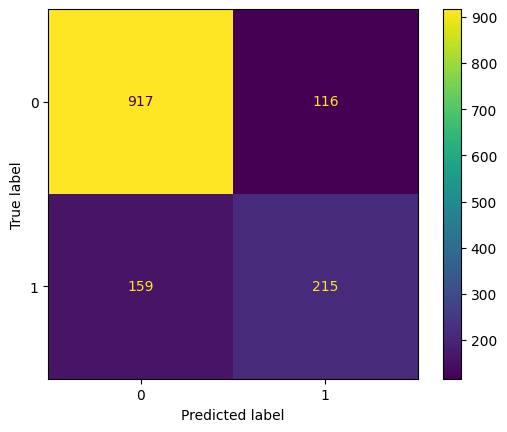

In [25]:
ConfusionMatrixDisplay.from_estimator(
    pipeline,
    X_test,
    y_test
)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [27]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8359342240812545

## Curva ROC

La curva **ROC (Receiver Operating Characteristic)** evalúa la capacidad del modelo para distinguir entre clientes que cancelan el servicio (*Churn = Yes*) y aquellos que permanecen (*Churn = No*). La curva muestra el compromiso entre la **tasa de verdaderos positivos (True Positive Rate)** y la **tasa de falsos positivos (False Positive Rate)** para todos los posibles umbrales de clasificación.

Un modelo con buen poder discriminativo presentará una curva cercana a la esquina superior izquierda, mientras que un modelo sin capacidad predictiva seguirá una línea diagonal equivalente a una clasificación aleatoria.

El desempeño global se resume mediante el **Área Bajo la Curva (ROC AUC)**, donde un valor cercano a **1** indica una excelente capacidad de discriminación y un valor cercano a **0.5** representa un modelo equivalente al azar.

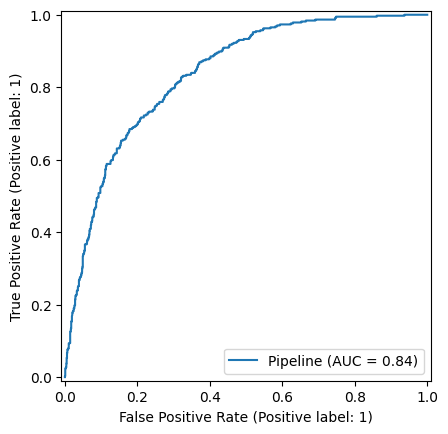

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    y_test
)

# 5. Evaluación y comparación de modelos

En esta sección se evalúa el desempeño de cada modelo utilizando métricas apropiadas para problemas de clasificación binaria, como Accuracy, Precision, Recall, F1-score y ROC AUC. Finalmente, se comparan los resultados para seleccionar el modelo con mejor capacidad predictiva y equilibrio entre rendimiento e interpretabilidad.

Evaluamos múltiples modelos usando las métricas más relevantes para este problema:

- **Recall (Churn=1)**: queremos capturar el mayor número posible de clientes que realmente van a abandonar
- **ROC-AUC**: mide la capacidad discriminativa general del modelo
- **Precisión**: evitar demasiadas falsas alarmas

In [29]:
results = []

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Entrena el pipeline y registra las métricas clave de evaluación."""
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Recall de churn (clase 1) es la métrica más importante:
    # queremos detectar la mayor cantidad posible de clientes que realmente van a abandonar
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })


## Entrenamiento de modelos de clasificación

Con el conjunto de datos preparado, se entrenan diferentes algoritmos de clasificación para predecir la probabilidad de **customer churn**.

Se seleccionaron modelos con características complementarias:

- **Regresión Logística:** modelo lineal ampliamente utilizado como línea base (*baseline*). Destaca por su interpretabilidad y eficiencia computacional.
- **Random Forest:** modelo basado en un conjunto de árboles de decisión capaz de capturar relaciones no lineales y reducir el riesgo de sobreajuste mediante agregación (*bagging*).
- **XGBoost:** algoritmo de *gradient boosting* reconocido por su alto desempeño en problemas de clasificación y por su capacidad para modelar patrones complejos.

Todos los modelos utilizan el mismo pipeline de preprocesamiento para garantizar una comparación justa, evitando diferencias derivadas del tratamiento de los datos.

In [30]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])


In [31]:

evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

evaluate_model(
    "XGBoost",
    xgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

summary = pd.DataFrame(results)

display(
    summary.sort_values("ROC AUC", ascending=False)
    .style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC AUC": "{:.3f}"
    })
    .background_gradient(
        subset=["ROC AUC"],
        cmap="Purples"
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.805,0.650,0.575,0.610,0.836
1,Random Forest,0.792,0.642,0.489,0.555,0.814
2,XGBoost,0.773,0.580,0.524,0.551,0.812


**Observación — Comparación de modelos:**

Los tres modelos evaluados (Regresión Logística, Random Forest, XGBoost) muestran métricas similares en este dataset

Se selecciona la **Regresión Logística** como modelo final por las siguientes razones:
- **Interpretabilidad**: compatible con SHAP LinearExplainer, lo que permite explicar cada predicción de forma clara al negocio
- **Rendimiento competitivo**: ROC-AUC similar a los modelos más complejos
- **Producción**: menor costo computacional y más fácil de auditar

En un escenario real, el criterio de selección debería priorizar el **Recall de la clase Churn=1**: es más costoso no detectar a un cliente que va a abandonar (falso negativo) que enviar una campaña de retención innecesaria (falso positivo).

# 6. Interpretabilidad del modelo con SHAP

El rendimiento predictivo es solo una parte del proceso de modelado. En esta etapa se emplea SHAP (*SHapley Additive exPlanations*) para comprender cómo cada variable contribuye a las predicciones del modelo. Este análisis permite identificar los principales factores asociados al churn y verificar si los hallazgos coinciden con los resultados obtenidos durante el análisis estadístico exploratorio.
SHAP (SHapley Additive exPlanations) nos permite entender **por qué** el modelo toma cada decisión, identificando qué variables empujan hacia el churn y cuáles lo reducen.

Esto es especialmente importante para comunicar los hallazgos a equipos de negocio que necesitan entender las razones detrás de cada predicción.

# SHAP

In [32]:
# Extraer el modelo y el preprocesador del pipeline para usarlos con SHAP
# SHAP necesita acceder al modelo y a los datos transformados por separado
model = logistic_pipeline.named_steps["model"]
preprocessor = logistic_pipeline.named_steps["preprocessor"]
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
feature_names[:20]

array(['cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_No',
       'cat__SeniorCitizen_Yes', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No'], dtype=object)

Background dataset has 1407 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1407 when initializing the masker.


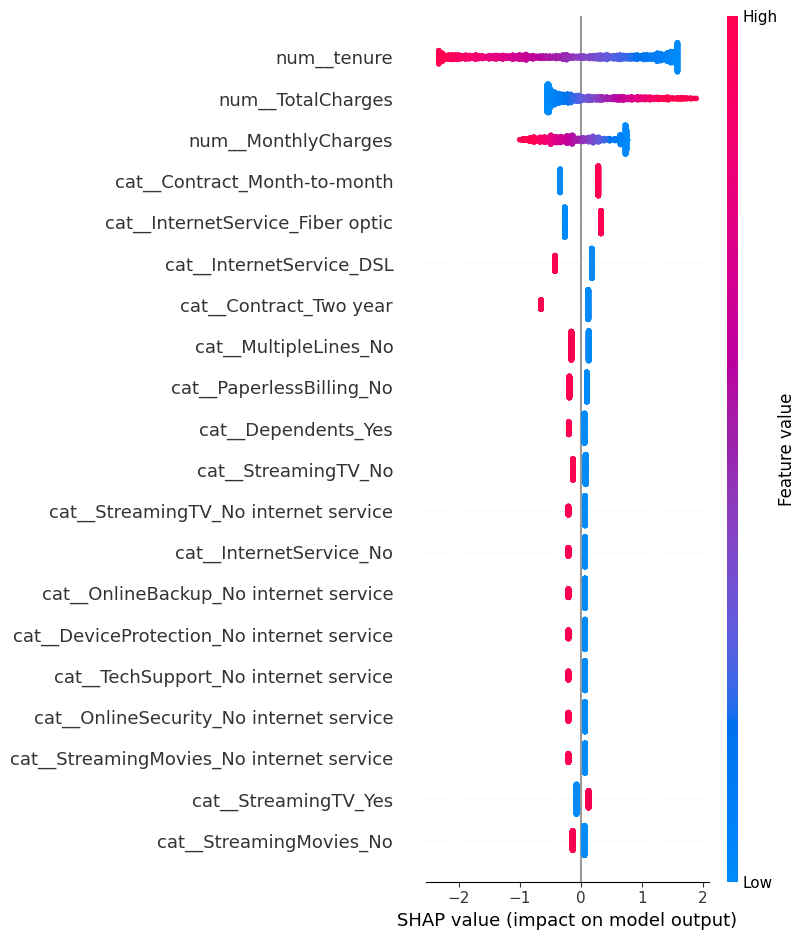

In [34]:
# Crear el explicador SHAP para el modelo de Regresión Logística
explainer = shap.LinearExplainer(
    model,
    X_test_transformed,
    max_samples=1407
)

# Calcular las contribuciones SHAP para cada observación
shap_values = explainer.shap_values(
    X_test_transformed
)

# Visualizar la importancia global de las variables
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### Interpretación

El gráfico ordena las variables según su contribución promedio al modelo.

- Las variables ubicadas en la parte superior son las que tienen mayor influencia sobre las predicciones.
- Los puntos rojos representan valores altos de una variable, mientras que los puntos azules representan valores bajos.
- Los valores SHAP positivos incrementan la probabilidad de **Churn = Yes**, mientras que los valores negativos favorecen la predicción de **Churn = No**.

Los resultados obtenidos muestran que variables como **tenure**, **TotalCharges**, **MonthlyCharges** y el tipo de **Contract** son los principales factores utilizados por el modelo para predecir el abandono de clientes, coincidiendo con los hallazgos obtenidos durante el análisis exploratorio y las pruebas estadísticas.

### Importancia global de variables

El siguiente gráfico muestra las **10 variables con mayor impacto** en las predicciones del modelo, de acuerdo con los valores SHAP.

Cada punto representa una observación del conjunto de prueba:

- La posición en el eje **X** indica cuánto contribuye la variable a aumentar o disminuir la probabilidad de *churn*.
- Los **valores SHAP positivos** desplazan la predicción hacia **Churn = Yes**, mientras que los **valores negativos** favorecen **Churn = No**.
- El color representa el valor de la variable: **rojo** indica valores altos y **azul** valores bajos.

Las variables se ordenan de mayor a menor importancia según el valor absoluto promedio de sus contribuciones SHAP.

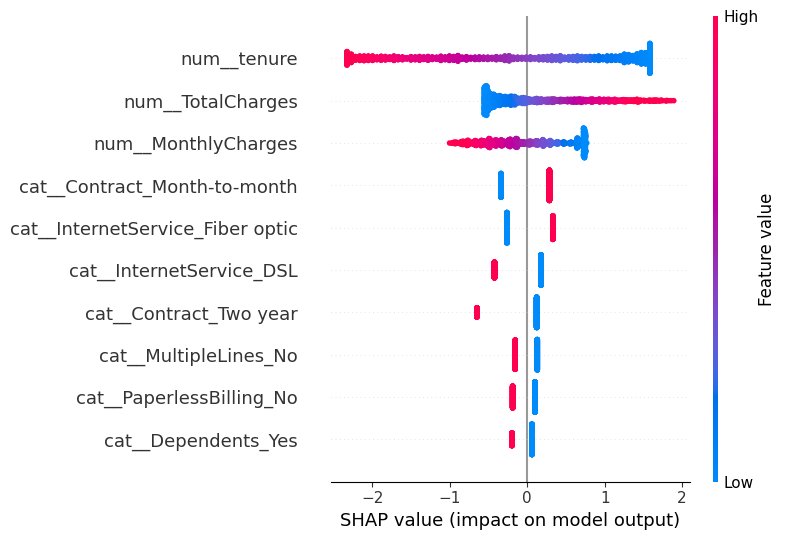

In [35]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=10
)

### Interpretación de los resultados

El modelo identifica la **antigüedad del cliente (`tenure`)** como el factor más influyente en la predicción del churn, seguida por **`TotalCharges`**, **`MonthlyCharges`** y el tipo de **contrato mensual (`Contract_Month-to-month`)**.

Estos resultados son consistentes con el análisis exploratorio realizado previamente, donde se observó que los clientes con menor antigüedad y contratos mes a mes presentan una mayor probabilidad de cancelar el servicio.

Asimismo, la alta relevancia de `TotalCharges` es consistente con su fuerte correlación con `tenure`, ya que representa el gasto acumulado del cliente a lo largo de su permanencia en la compañía.

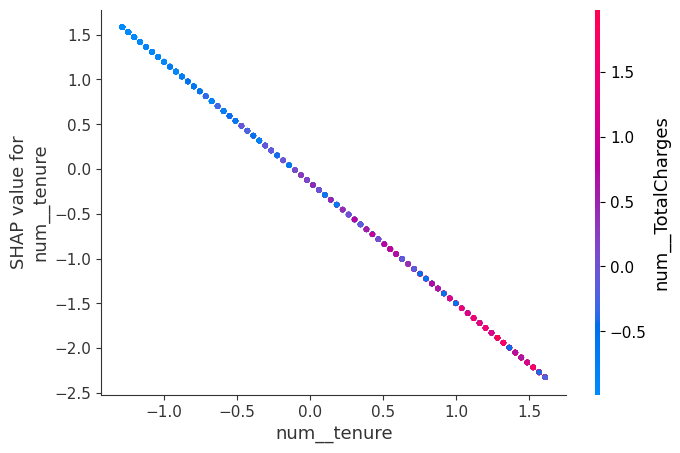

In [36]:
shap.dependence_plot(
    "num__tenure",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### Explicación individual — ejemplo de cliente

El gráfico waterfall muestra cómo cada variable empuja la predicción hacia churn o retención para un cliente específico.

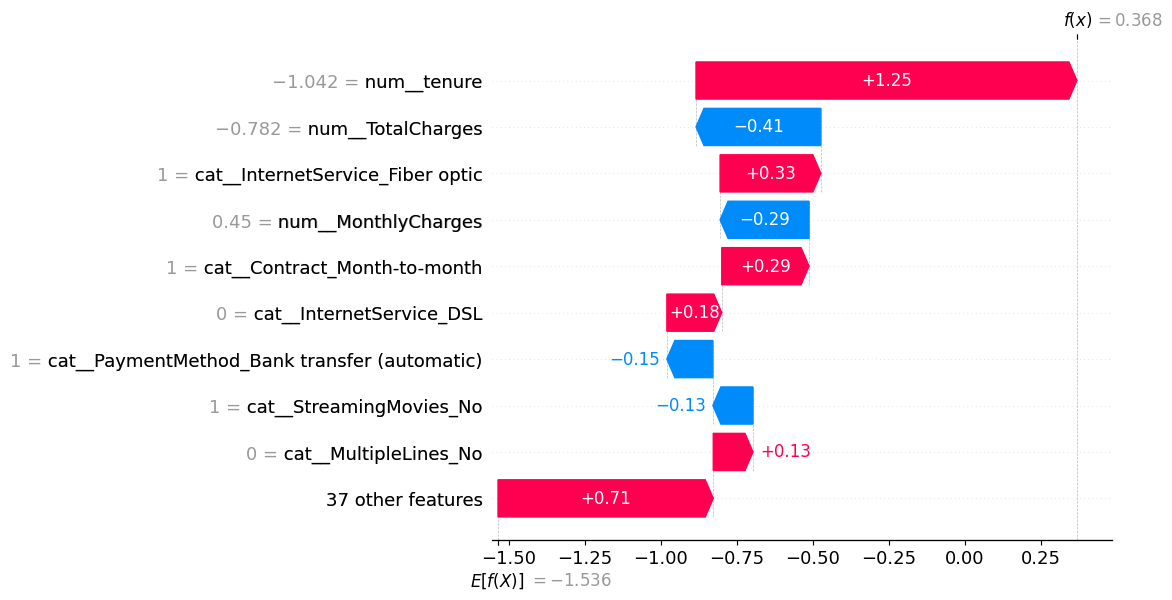

In [37]:
i = 1
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_transformed[i],
        feature_names=feature_names
    )
)

# 7. Exportación del modelo final

Una vez seleccionado el mejor modelo, se guarda junto con su pipeline de preprocesamiento para facilitar su reutilización en nuevos datos. Esta etapa permite disponer de un modelo reproducible y listo para integrarse en aplicaciones o sistemas de apoyo a la toma de decisiones.

Guardamos el pipeline completo (preprocesamiento + modelo) como archivo `.pkl` para su reutilización en producción o en una aplicación de predicción.

In [38]:
joblib.dump(
    logistic_pipeline,
    "churn_model.pkl"
)

['churn_model.pkl']

In [39]:
loaded_model = joblib.load("churn_model.pkl")

In [40]:
# Ejemplo de predicción sobre un cliente del conjunto de prueba
prediction = loaded_model.predict(X_test.iloc[[1]])
probability = loaded_model.predict_proba(X_test.iloc[[1]])[:,1]

print(f"Predicción: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Probabilidad de abandono: {probability[0]:.2%}")

Predicción: Churn
Probabilidad de abandono: 59.11%


## Hallazgos clave

### 1. El tipo de contrato es el factor más determinante

Los clientes con contratos mes a mes tienen una tasa de abandono significativamente mayor que aquellos con contratos anuales o bianuales. Esto sugiere que incentivar contratos de mayor duración es una de las palancas de retención más efectivas.

### 2. La antigüedad del cliente protege contra el churn

A mayor `tenure` (tiempo como cliente), menor probabilidad de abandono. Los clientes nuevos (primeros 12 meses) representan el grupo de mayor riesgo y deberían ser prioridad en estrategias de onboarding y retención temprana.

### 3. Los cargos mensuales altos se asocian con mayor riesgo

Clientes con `MonthlyCharges` elevados muestran mayor tendencia al abandono, especialmente cuando se combinan con contratos mes a mes. Revisar la propuesta de valor para este segmento podría reducir la tasa de churn.

### 4. El modelo captura correctamente los patrones de abandono

La Regresión Logística alcanzó un ROC-AUC competitivo con alta interpretabilidad, lo que la hace adecuada para este caso de uso donde explicar las predicciones al negocio es tan importante como la precisión del modelo.

## Conclusión

Este proyecto demuestra un flujo completo de ciencia de datos aplicado a un problema real de negocio: desde el análisis estadístico de asociación hasta la exportación de un modelo listo para producción. El pipeline construido es directamente aplicable a datos reales de telecomunicaciones, retail o cualquier industria donde la retención de clientes sea estratégica.